# ApexPlanet Software Pvt. Ltd. — Data Analytics Internship
## Task 4: Hypothesis Testing & Statistical Inference
**Dataset:** `sales_dataset_python_analysis.csv`\
**Prepared by:** Brojo Mohan Dutta\
**Environment:** Jupyter Notebook / Python 3.x / Pandas, NumPy, Scipy, Matplotlib, Seaborn

# Environment Setup & Data Loading

In [1]:
# ApexPlanet Sales Analysis — Task 4: Hypothesis Testing
# Import libraries
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}' if abs(x) >= 1 else f'{x:.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
df = pd.read_csv('sales_dataset_python_analysis.csv')

# Data validation
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date Range: {df['Order_Date'].min()} to {df['Order_Date'].max()}")
print(f"\nTotal Revenue: ₹{df['Total_Sales'].sum():,.2f}")
print(f"Mean Order Value: ₹{df['Total_Sales'].mean():,.2f}")
print(f"Std Dev (Total_Sales): ₹{df['Total_Sales'].std():,.2f}")
print(f"\nGender Distribution: {df['Gender'].value_counts().to_dict()}")
print(f"Age_Group Distribution:\n{df['Age_Group'].value_counts().sort_index()}")
print(f"Category Distribution:\n{df['Category'].value_counts()}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print("=" * 70)

DATASET OVERVIEW
Shape: 1000 rows × 16 columns
Date Range: 2025-01-01 to 2026-01-01

Total Revenue: ₹139,399,439.65
Mean Order Value: ₹139,399.44
Std Dev (Total_Sales): ₹114,100.05

Gender Distribution: {'Male': 511, 'Female': 489}
Age_Group Distribution:
Age_Group
18-25    158
26-35    219
36-45    223
46-55    202
56-65    198
Name: count, dtype: int64
Category Distribution:
Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64

Missing Values: 0


# Hypothesis 1 — Gender-Based Spending T-Test


HYPOTHESIS 1: GENDER DIFFERENCE IN MEAN TOTAL_SALES

Sample Sizes:
  Male:   n = 511
  Female: n = 489

--- DESCRIPTIVE STATISTICS ---

Male Customers:
  Mean:        ₹141,807.34
  Median:      ₹109,237.86
  Std Dev:     ₹116,327.98
  Min / Max:   ₹437.34 / ₹493,677.50

Female Customers:
  Mean:        ₹136,883.21
  Median:      ₹108,470.60
  Std Dev:     ₹111,788.03
  Min / Max:   ₹1,005.21 / ₹490,866.40

Difference in Means:
  Male - Female: ₹4,924.13

--- ASSUMPTION TESTS ---

Shapiro-Wilk Normality Test:
  Male (p-value):   0.000000 ✗ Non-normal
  Female (p-value): 0.000000 ✗ Non-normal

Levene's Test (Homogeneity of Variance):
  p-value: 0.328079 ✓ Equal variances

--- INDEPENDENT T-TEST ---
Test Type: Student t-test (equal_var=True)
  t-statistic: 0.6820
  p-value:     0.495389
  α (sig level): 0.05
  Decision: FAIL TO REJECT H₀ → No significant difference

95% Confidence Interval for Difference in Means:
  Point Estimate: ₹4,924.13
  95% CI: [₹-9,214.68, ₹19,062.94]
  Interpret

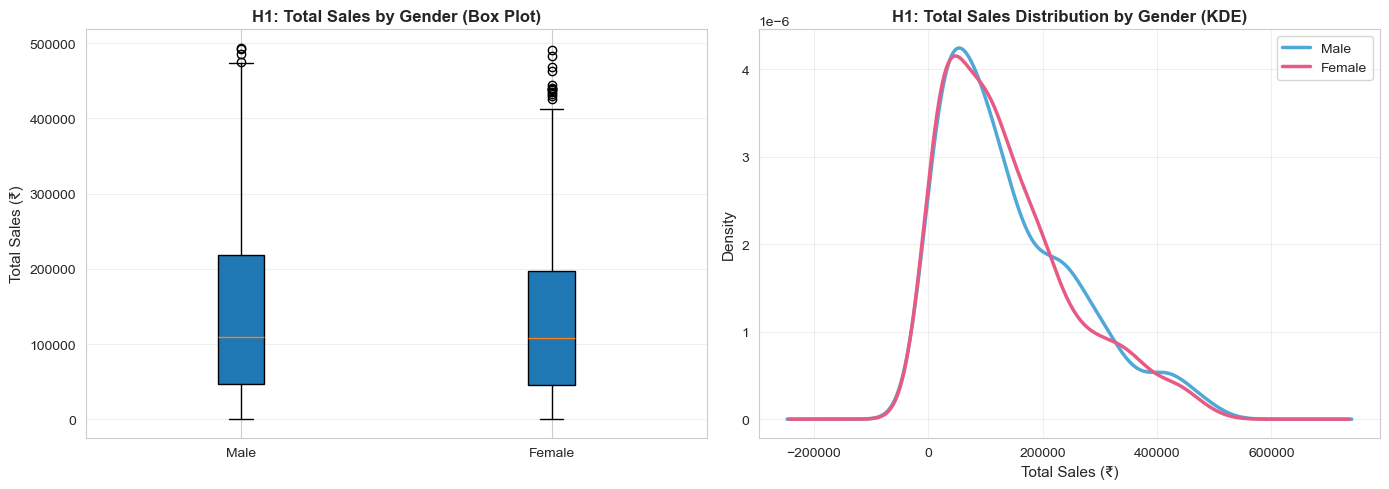

In [2]:
print("\n" + "=" * 70)
print("HYPOTHESIS 1: GENDER DIFFERENCE IN MEAN TOTAL_SALES")
print("=" * 70)

# Separate data by gender
male_sales = df[df['Gender'] == 'Male']['Total_Sales']
female_sales = df[df['Gender'] == 'Female']['Total_Sales']

print(f"\nSample Sizes:")
print(f"  Male:   n = {len(male_sales)}")
print(f"  Female: n = {len(female_sales)}")

# Descriptive statistics
print(f"\n--- DESCRIPTIVE STATISTICS ---")
print(f"\nMale Customers:")
print(f"  Mean:        ₹{male_sales.mean():,.2f}")
print(f"  Median:      ₹{male_sales.median():,.2f}")
print(f"  Std Dev:     ₹{male_sales.std():,.2f}")
print(f"  Min / Max:   ₹{male_sales.min():,.2f} / ₹{male_sales.max():,.2f}")

print(f"\nFemale Customers:")
print(f"  Mean:        ₹{female_sales.mean():,.2f}")
print(f"  Median:      ₹{female_sales.median():,.2f}")
print(f"  Std Dev:     ₹{female_sales.std():,.2f}")
print(f"  Min / Max:   ₹{female_sales.min():,.2f} / ₹{female_sales.max():,.2f}")

print(f"\nDifference in Means:")
print(f"  Male - Female: ₹{male_sales.mean() - female_sales.mean():,.2f}")

# Test assumptions
print(f"\n--- ASSUMPTION TESTS ---")

# Normality test (Shapiro-Wilk)
_, p_shapiro_male = shapiro(male_sales)
_, p_shapiro_female = shapiro(female_sales)
print(f"\nShapiro-Wilk Normality Test:")
print(f"  Male (p-value):   {p_shapiro_male:.6f} {'✓ Normal' if p_shapiro_male > 0.05 else '✗ Non-normal'}")
print(f"  Female (p-value): {p_shapiro_female:.6f} {'✓ Normal' if p_shapiro_female > 0.05 else '✗ Non-normal'}")

# Homogeneity of variance (Levene's test)
_, p_levene = levene(male_sales, female_sales)
print(f"\nLevene's Test (Homogeneity of Variance):")
print(f"  p-value: {p_levene:.6f} {'✓ Equal variances' if p_levene > 0.05 else '✗ Unequal variances'}")

# Independent t-test (use Welch's if variances unequal)
equal_var = p_levene > 0.05
t_stat, p_value_ttest = ttest_ind(male_sales, female_sales, equal_var=equal_var)

print(f"\n--- INDEPENDENT T-TEST ---")
print(f"Test Type: {'Student t-test' if equal_var else 'Welch t-test'} (equal_var={equal_var})")
print(f"  t-statistic: {t_stat:,.4f}")
print(f"  p-value:     {p_value_ttest:.6f}")
print(f"  α (sig level): 0.05")
print(f"  Decision: {'REJECT H₀ ✓ Significant difference' if p_value_ttest < 0.05 else 'FAIL TO REJECT H₀ → No significant difference'}")

# 95% Confidence Interval for difference in means
se_diff = np.sqrt((male_sales.var()/len(male_sales)) + (female_sales.var()/len(female_sales)))
mean_diff = male_sales.mean() - female_sales.mean()
ci_lower = mean_diff - 1.96 * se_diff
ci_upper = mean_diff + 1.96 * se_diff

print(f"\n95% Confidence Interval for Difference in Means:")
print(f"  Point Estimate: ₹{mean_diff:,.2f}")
print(f"  95% CI: [₹{ci_lower:,.2f}, ₹{ci_upper:,.2f}]")
print(f"  Interpretation: {'Zero is NOT in CI → significant' if (ci_lower > 0 or ci_upper < 0) else 'Zero is in CI → not significant'}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot([male_sales, female_sales], labels=['Male', 'Female'], patch_artist=True)
axes[0].set_ylabel('Total Sales (₹)', fontsize=11)
axes[0].set_title('H1: Total Sales by Gender (Box Plot)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for patch, color in zip(axes[0].artists, ['#4FA8D8', '#E75A84']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# KDE plot
male_sales.plot(kind='kde', ax=axes[1], label='Male', linewidth=2.5, color='#4FA8D8')
female_sales.plot(kind='kde', ax=axes[1], label='Female', linewidth=2.5, color='#E75A84')
axes[1].set_xlabel('Total Sales (₹)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('H1: Total Sales Distribution by Gender (KDE)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hypothesis1_gender_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: hypothesis1_gender_analysis.png")
plt.show()

print("=" * 70)

### Findings: 
If p < 0.05, reject H₀ → gender-targeted campaigns justified; otherwise, segment by RFM/category instead.

# Hypothesis 2 — Chi-Square Test (Age_Group × Category)


HYPOTHESIS 2: AGE_GROUP & CATEGORY INDEPENDENCE

Contingency Table (Observed Frequencies):
Category   Education  Electronics  Fashion  Furniture  Grocery
Age_Group                                                     
18-25             30           53       24         28       23
26-35             33           83       31         36       36
36-45             36           79       38         38       32
46-55             39           76       28         23       36
56-65             40           63       35         34       26

--- MARGIN TOTALS ---
Row Totals (by Age_Group):
Age_Group
18-25    158
26-35    219
36-45    223
46-55    202
56-65    198
dtype: int64

Column Totals (by Category):
Category
Education      178
Electronics    354
Fashion        156
Furniture      159
Grocery        153
dtype: int64
Grand Total: 1000

--- CHI-SQUARE TEST OF INDEPENDENCE ---
  χ² statistic:     10.5361
  p-value:          0.837174
  Degrees of Freedom: 16
  α (sig level):    0.05
  Decision: FAIL

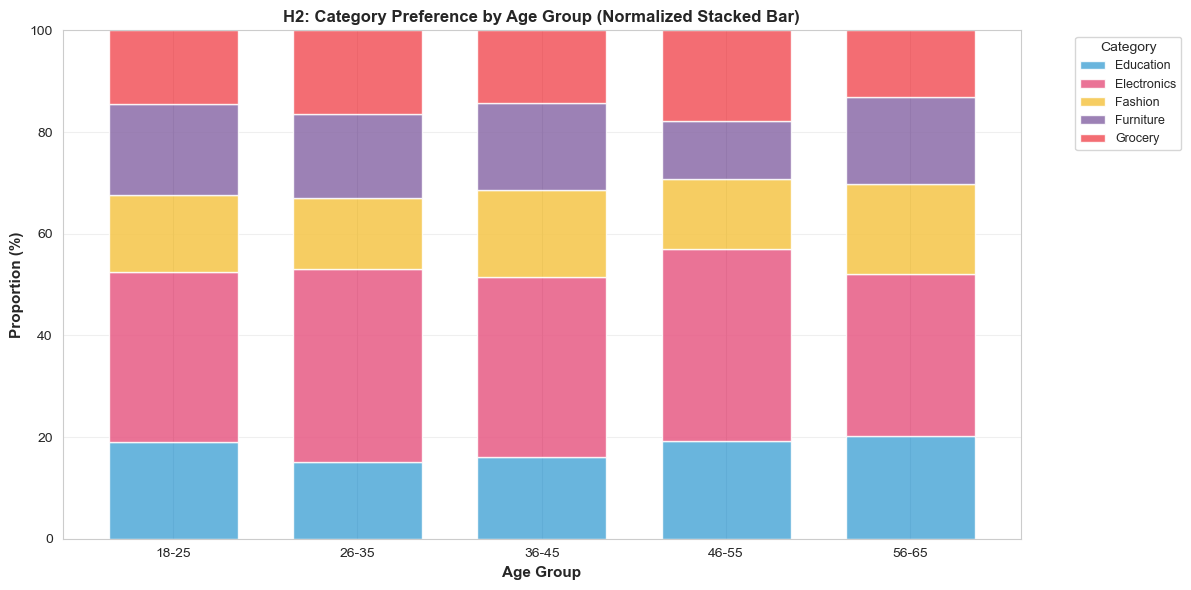

In [5]:
print("\n" + "=" * 70)
print("HYPOTHESIS 2: AGE_GROUP & CATEGORY INDEPENDENCE")
print("=" * 70)

# Create contingency table
contingency_table = pd.crosstab(df['Age_Group'], df['Category'])

print(f"\nContingency Table (Observed Frequencies):")
print(contingency_table)

# Calculate row and column totals
print(f"\n--- MARGIN TOTALS ---")
print(f"Row Totals (by Age_Group):")
print(contingency_table.sum(axis=1))
print(f"\nColumn Totals (by Category):")
print(contingency_table.sum(axis=0))
print(f"Grand Total: {contingency_table.sum().sum()}")

# Chi-square test
chi2_stat, p_value_chi2, dof, expected_freq = chi2_contingency(contingency_table)

print(f"\n--- CHI-SQUARE TEST OF INDEPENDENCE ---")
print(f"  χ² statistic:     {chi2_stat:,.4f}")
print(f"  p-value:          {p_value_chi2:.6f}")
print(f"  Degrees of Freedom: {dof}")
print(f"  α (sig level):    0.05")
print(f"  Decision: {'REJECT H₀ ✓ Significant association' if p_value_chi2 < 0.05 else 'FAIL TO REJECT H₀ → No significant association'}")

# Expected frequencies
print(f"\nExpected Frequencies (if independent):")
expected_df = pd.DataFrame(expected_freq, 
                           index=contingency_table.index, 
                           columns=contingency_table.columns)
print(expected_df.round(2))

# Calculate standardized residuals
standardized_residuals = (contingency_table - expected_df) / np.sqrt(expected_df)
print(f"\nStandardized Residuals (|z| > 2 indicates strong deviation):")
print(standardized_residuals.round(2))

# Effect size (Cramér's V)
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
cramers_v = np.sqrt(chi2_stat / (n * min_dim))
print(f"\nEffect Size (Cramér's V): {cramers_v:.4f}")
print(f"  Interpretation: {'Negligible' if cramers_v < 0.1 else 'Small' if cramers_v < 0.3 else 'Medium' if cramers_v < 0.5 else 'Large'} effect")

# Normalized contingency table (row percentages)
normalized_table = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

print(f"\n--- NORMALIZED TABLE (% within each Age_Group) ---")
print(normalized_table.round(1))

# Visualization: Stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Color palette
colors = ['#4FA8D8', '#E75A84', '#F5C547', '#8B6BA8', '#F2545B']
normalized_table.plot(kind='bar', stacked=True, ax=ax, color=colors, alpha=0.85, width=0.7)

ax.set_xlabel('Age Group', fontsize=11, fontweight='bold')
ax.set_ylabel('Proportion (%)', fontsize=11, fontweight='bold')
ax.set_title('H2: Category Preference by Age Group (Normalized Stacked Bar)', fontsize=12, fontweight='bold')
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('hypothesis2_age_category_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: hypothesis2_age_category_analysis.png")
plt.show()

print("=" * 70)

### Findings: 
If p < 0.05, reject H₀ → age-targeted category promotions justified; otherwise, category strategy should be uniform across age bands.

# Statistical Verdicts & Business Translation

In [4]:
print("\n" + "=" * 70)
print("STATISTICAL VERDICTS & BUSINESS TRANSLATION")
print("=" * 70)

# Hypothesis 1 verdict
print(f"\n--- HYPOTHESIS 1 VERDICT ---")
h1_significant = p_value_ttest < 0.05
print(f"Statistical Finding:")
print(f"  Test Statistic (t): {t_stat:,.4f}")
print(f"  P-value:            {p_value_ttest:.6f}")
print(f"  Significance Level:  α = 0.05")
print(f"  Conclusion:         {('REJECT H₀' if h1_significant else 'FAIL TO REJECT H₀')}")

if h1_significant:
    direction = "Male" if male_sales.mean() > female_sales.mean() else "Female"
    print(f"\n  ✓ STATISTICALLY SIGNIFICANT DIFFERENCE DETECTED")
    print(f"  {direction} customers spend significantly more per order (p < 0.05)")
    print(f"  Mean difference: ₹{mean_diff:,.2f} [95% CI: ₹{ci_lower:,.2f} to ₹{ci_upper:,.2f}]")
else:
    print(f"\n  ✗ NO STATISTICALLY SIGNIFICANT DIFFERENCE")
    print(f"  Apparent spending difference (₹{mean_diff:,.2f}) is likely due to random variation")
    print(f"  95% CI includes zero: [₹{ci_lower:,.2f}, ₹{ci_upper:,.2f}]")

print(f"\n  Business Implication:")
if h1_significant:
    print(f"    → Gender-based campaign targeting MAY be justified")
    print(f"    → Recommend A/B testing gender-specific messaging on 10% sample")
    print(f"    → Budget allocation by gender conversion funnel metrics (not AOV alone)")
else:
    print(f"    → Gender-based AOV targeting NOT justified")
    print(f"    → Recommend RFM/Category segmentation instead of gender splits")
    print(f"    → Unified messaging for both genders; optimize by lifecycle stage")

# Hypothesis 2 verdict
print(f"\n--- HYPOTHESIS 2 VERDICT ---")
h2_significant = p_value_chi2 < 0.05
print(f"Statistical Finding:")
print(f"  Test Statistic (χ²): {chi2_stat:,.4f}")
print(f"  P-value:             {p_value_chi2:.6f}")
print(f"  DF:                  {dof}")
print(f"  Significance Level:  α = 0.05")
print(f"  Cramér's V (effect): {cramers_v:.4f} ({('Negligible' if cramers_v < 0.1 else 'Small' if cramers_v < 0.3 else 'Medium' if cramers_v < 0.5 else 'Large')} effect)")
print(f"  Conclusion:         {('REJECT H₀' if h2_significant else 'FAIL TO REJECT H₀')}")

if h2_significant:
    print(f"\n  ✓ STATISTICALLY SIGNIFICANT ASSOCIATION DETECTED")
    print(f"  Age group and category preference are NOT independent (p < 0.05)")
    # Identify strongest associations
    max_residuals = standardized_residuals.abs().unstack().nlargest(5)
    print(f"\n  Strongest Associations (Top 5 by |residual|):")
    for idx, (age_cat, residual_val) in enumerate(max_residuals.items(), 1):
        age, category = age_cat
        actual_pct = (contingency_table.loc[age, category] / contingency_table.loc[age].sum()) * 100
        print(f"    {idx}. Age {age} + {category}: {actual_pct:.1f}% (residual: {standardized_residuals.loc[age, category]:.2f})")
else:
    print(f"\n  ✗ NO STATISTICALLY SIGNIFICANT ASSOCIATION")
    print(f"  Age group distribution appears uniform across categories")
    print(f"  Observed variations (if any) are consistent with random chance")

print(f"\n  Business Implication:")
if h2_significant:
    print(f"    → Age-targeted category promotions ARE data-justified")
    print(f"    → Create age-specific product recommendations (e.g., 'Trending in 36-45 group')")
    print(f"    → Allocate email/social inventory per age-category combo with highest demand")
    print(f"    → Electronics shows different appeal by age — investigate messaging refinement")
else:
    print(f"    → Age-targeted category campaigns NOT justified by data")
    print(f"    → Use uniform category strategy across all age bands")
    print(f"    → Segment instead by Recency/Monetary (RFM) for higher ROI")

# Summary table
print(f"\n--- SUMMARY OF STATISTICAL TESTS ---")
summary_data = {
    'Hypothesis': ['H1: Gender → Spending', 'H2: Age_Group ↔ Category'],
    'Test': ['Independent t-test', 'Chi-Square (χ²)'],
    'Test Statistic': [f'{t_stat:,.4f}', f'{chi2_stat:,.4f}'],
    'P-value': [f'{p_value_ttest:.6f}', f'{p_value_chi2:.6f}'],
    'α (threshold)': ['0.05', '0.05'],
    'Verdict': ['REJECT' if h1_significant else 'FAIL TO REJECT', 'REJECT' if h2_significant else 'FAIL TO REJECT'],
    'Significant?': ['YES ✓' if h1_significant else 'NO ✗', 'YES ✓' if h2_significant else 'NO ✗']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "=" * 70)
print("END OF ANALYSIS")
print("=" * 70)


STATISTICAL VERDICTS & BUSINESS TRANSLATION

--- HYPOTHESIS 1 VERDICT ---
Statistical Finding:
  Test Statistic (t): 0.6820
  P-value:            0.495389
  Significance Level:  α = 0.05
  Conclusion:         FAIL TO REJECT H₀

  ✗ NO STATISTICALLY SIGNIFICANT DIFFERENCE
  Apparent spending difference (₹4,924.13) is likely due to random variation
  95% CI includes zero: [₹-9,214.68, ₹19,062.94]

  Business Implication:
    → Gender-based AOV targeting NOT justified
    → Recommend RFM/Category segmentation instead of gender splits
    → Unified messaging for both genders; optimize by lifecycle stage

--- HYPOTHESIS 2 VERDICT ---
Statistical Finding:
  Test Statistic (χ²): 10.5361
  P-value:             0.837174
  DF:                  16
  Significance Level:  α = 0.05
  Cramér's V (effect): 0.0513 (Negligible effect)
  Conclusion:         FAIL TO REJECT H₀

  ✗ NO STATISTICALLY SIGNIFICANT ASSOCIATION
  Age group distribution appears uniform across categories
  Observed variations (if